In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

df = df.drop('customerID',axis=1)

In [3]:
df["TotalCharges"] = df["TotalCharges"].replace({" ":"0.0"}).astype(float)

In [4]:
df["Churn"].value_counts()

print(f"CLass imbalance ratio : {df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1]:.2f} : 1")

CLass imbalance ratio : 2.77 : 1


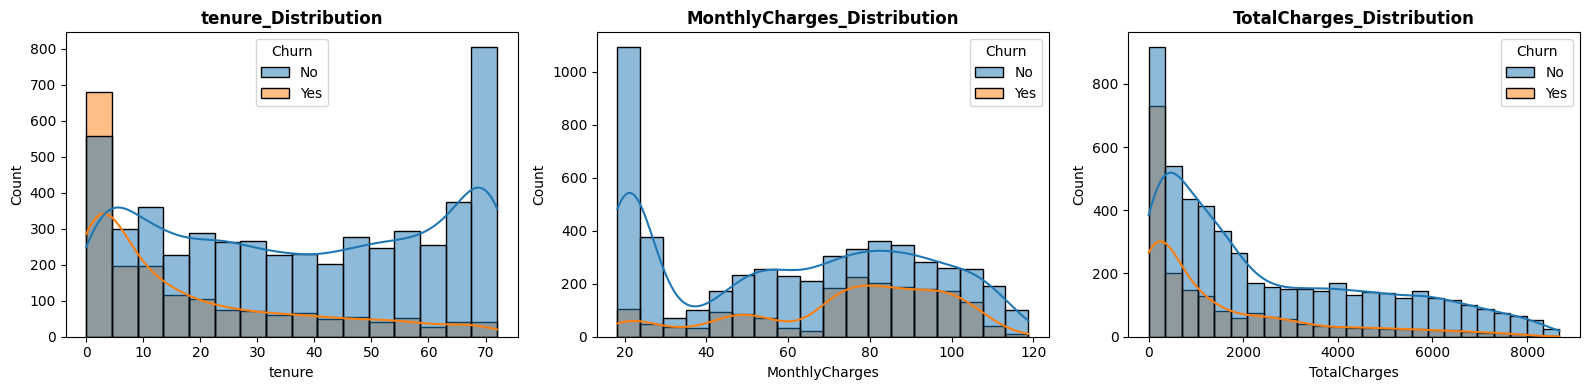

In [5]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
for idx, col in enumerate(["tenure","MonthlyCharges","TotalCharges"]):
    sns.histplot(data =df,x=col,kde =True,ax=axes[idx],hue=df['Churn'])
    axes[idx].set_title(f'{col}_Distribution',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()

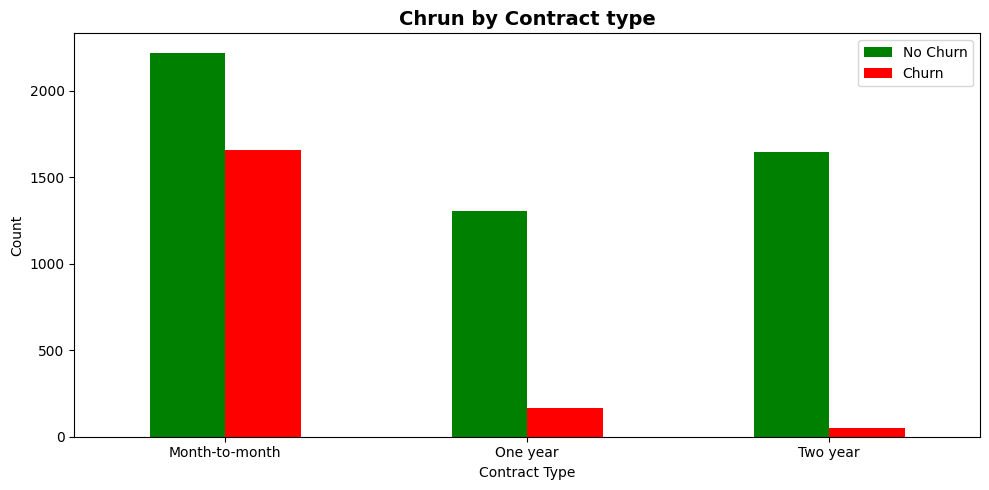

In [6]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
contract_churn = df.groupby(['Contract','Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind ='bar',stacked=False,ax=ax,color=['green','red'])
ax.set_title("Chrun by Contract type",fontsize=14,fontweight='bold')
ax.set_xlabel("Contract Type")
ax.set_ylabel("Count")
ax.legend(['No Churn','Churn'])
ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
plt.tight_layout()
plt.show()

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [9]:
binary_col = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in binary_col:
    df[col] = df[col].map({'Yes':1,'No':0})

df['gender'] = df['gender'].map({'Male':1,'Female':0})

categorical_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

In [10]:
x = df.drop('Churn',axis=1)
y = df['Churn']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

x_train.shape[0]

5634

In [11]:
x_test.shape[0]

1409

In [12]:
smote = SMOTE(random_state=42)

x_train_balance , y_train_balance = smote.fit_resample(x_train,y_train)

dict(y_train.value_counts())

{0: np.int64(4139), 1: np.int64(1495)}

In [13]:
dict(y_train_balance.value_counts())

{0: np.int64(4139), 1: np.int64(4139)}

In [14]:
params = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    params,
    n_iter=50,
    scoring='f1',        # optimize for F1 specifically
    cv=5,
    random_state=42
)
search.fit(x_train_balance, y_train_balance)

print(search.best_params_)
best_model = search.best_estimator_

{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [15]:
# xgb_model = XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.3,random_state=42)

# xgb_model.fit(x_train_balance,y_train_balance)

In [16]:
# y_pred_proba = best_model.predict_proba(x_test)[:, 1]

# # Try different thresholds
# for threshold in [0.5, 0.4, 0.3, 0.25]:
#     y_pred = (y_pred_proba >= threshold).astype(int)
#     f1 = f1_score(y_test, y_pred)
#     print(f"Threshold {threshold}: F1 = {f1:.4f}")

In [17]:
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

train_acc = accuracy_score(y_train,y_train_pred)
test_acc = accuracy_score(y_test,y_test_pred)

In [18]:
print('Training accuracy',train_acc)
print('Test accuracy',test_acc)

Training accuracy 0.8093716719914803
Test accuracy 0.7672107877927609


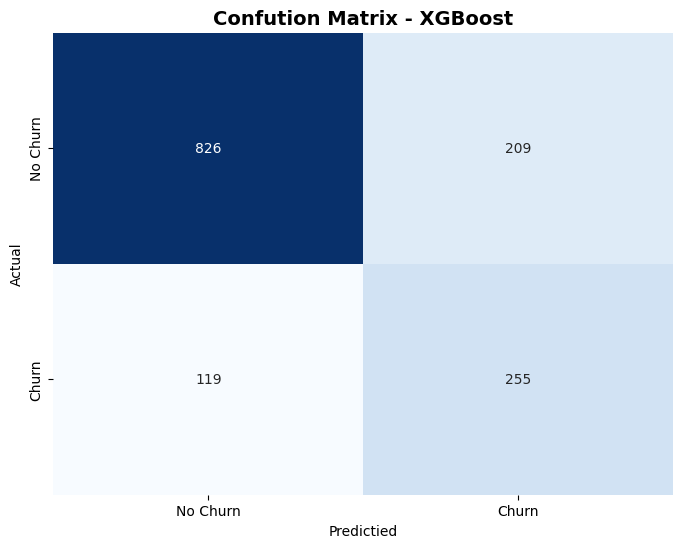

In [19]:
cm =confusion_matrix(y_test,y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',cbar=False, xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])
plt.title("Confution Matrix - XGBoost" , fontsize = 14,fontweight='bold')
plt.xlabel('Predictied')
plt.ylabel('Actual')

plt.show()

In [20]:
feature_importance = pd.DataFrame({
    'Feature' : x.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance',ascending=True)

feature_importance.tail(10)[::-1]

,Feature,Importance
14,Contract,0.452642
8,OnlineSecurity,0.082420
11,TechSupport,0.076185
3,Dependents,0.049735
7,InternetService,0.049616
9,OnlineBackup,0.036964
10,DeviceProtection,0.028818
5,PhoneService,0.027555
4,tenure,0.022468
17,MonthlyCharges,0.022369


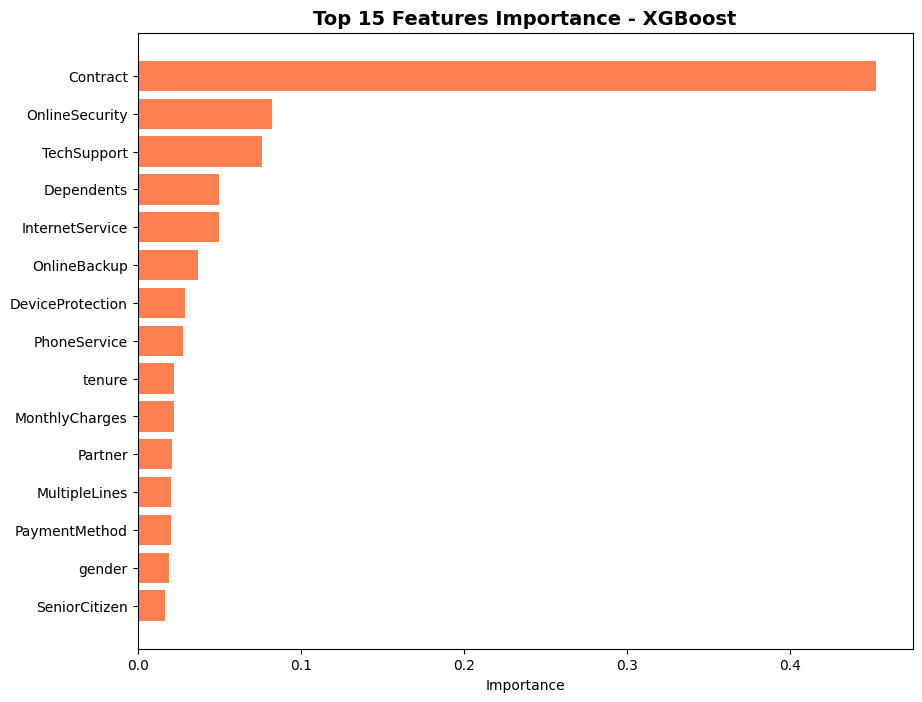

In [21]:
plt.figure(figsize=(10,8))

plt.barh(feature_importance['Feature'][-15:],feature_importance['Importance'][-15:],color='coral')
plt.xlabel('Importance')
plt.title('Top 15 Features Importance - XGBoost', fontsize = 14, fontweight='bold')

plt.show()

In [22]:
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409



In [23]:
joblib.dump(best_model,'customer_churn_model.pkl')
joblib.dump(encoders,' churn_encoders.pkl')

[' churn_encoders.pkl']